# PINN-C with Inverse Dirichlet Weighting
### CHE 891 — Week 4

Extends `week3_VdV_PINN.ipynb` by replacing fixed loss weights $\lambda_1 = \lambda_2 = 1$
with **Inverse Dirichlet Weighting (IDW)** (Maddu et al., 2022).

IDW sets $\lambda_i \propto \|\nabla_\theta \mathcal{L}_\text{data}\|^2 / \|\nabla_\theta \mathcal{L}_i\|^2$
so that every loss component contributes equal gradient energy to each update.
Applied *during* Adam training (not as a post-hoc step), this prevents the
data loss from dominating the physics loss that constrains $k_1, k_2, k_3$.

**Reference:** S. Maddu et al., *Inverse Dirichlet weighting enables reliable
training of physics informed neural networks*, Mach. Learn.: Sci. Technol. **3**, 015026 (2022).

In [1]:
import builtins
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.pyplot import *

builtins_sum = builtins.sum   # preserve before pyplot can shadow it

torch.manual_seed(42)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'PyTorch {torch.__version__} — device: {device}')

PyTorch 2.5.1+cu121 — device: cuda


## 1. Load Dataset

Generated in `week3_VdV_reactor.ipynb` using the full Arrhenius model.
We treat $k_1, k_2, k_3$ as ground truth for validation only — the PINN
does not see these during training.

In [2]:
data   = np.load('vdv_dataset.npz')
t_s    = data['t']        # (101,)       time in seconds
X      = data['X']        # (100, 101, 4) measured states [c_A, c_B, T, T_K]
U      = data['U']        # (100, 2)      inputs [D, Q_dot_K]
X0     = data['X0']       # (100, 4)      initial conditions
K_true = data['k_true']   # (100, 101, 3) ground-truth [k1, k2, k3]

N_traj, N_t, _ = X.shape
print(f'{N_traj} trajectories, {N_t} time steps each')

# Physical time in hours
t_h   = t_s / 3600        # (101,)
t_max = t_h[-1]           # 1/60 h

100 trajectories, 101 time steps each


## 2. Physical Parameters and Normalization

Inputs $(t, \mathbf{x}^m_0, \mathbf{u})$ and loss terms are normalized using
**mean-std (z-score)** standardization for consistency.
Network outputs are in physical units throughout.

In [3]:
# Physical constants (Table 2)
c_A_in = 5.10    # mol/L       feed concentration of A
T_in   = 378.1   # K           feed temperature
dH_AB  = 4.2     # kJ/mol      heat of reaction A→B
dH_BC  = -11.0   # kJ/mol      heat of reaction B→C
dH_AD  = -41.85  # kJ/mol      heat of reaction 2A→D
rho    = 0.9342  # kg/L        liquid density
Cp     = 3.01    # kJ/(kg·K)   heat capacity of reaction mixture
CpK    = 2.00    # kJ/(kg·K)   heat capacity of coolant
kw     = 4032.0  # kJ/(h·m²·K) wall heat transfer coefficient
AR     = 0.215   # m²          heat transfer area
VR     = 10.0    # L           reactor volume (0.01 m³)
mK     = 5.0     # kg          coolant mass

# Input normalisation — mean-std computed from the full dataset
x0_mean = torch.tensor(X0.mean(axis=0), dtype=torch.float32, device=device)
x0_std  = torch.tensor(X0.std(axis=0),  dtype=torch.float32, device=device)
u_mean  = torch.tensor(U.mean(axis=0),  dtype=torch.float32, device=device)
u_std   = torch.tensor(U.std(axis=0),   dtype=torch.float32, device=device)

def norm_x0(x):  return (x - x0_mean) / x0_std
def norm_u(u):   return (u - u_mean)  / u_std
def norm_t(t):   return t / t_max
def denorm_u(u): return u * u_std + u_mean

# Physics residual scales: typical ODE RHS magnitude in physical units
# dc/dt  ~ state_range × 60 h⁻¹  (60 = 1 / t_max in 1/h)
# dT/dt  ~ similar × 60
phys_scales = torch.tensor([30.0, 15.0, 960.0, 900.0], dtype=torch.float32, device=device)

# state_scales (for loss normalisation) computed below in data_prep from xm_tr.std()

# Output-layer bias for NN: start predictions near physical state means
# [c_A_mean, c_B_mean, T_mean, T_K_mean, k1_est, k2_est, k3_est]
out_bias_vals = torch.tensor(
    [2.35, 0.98, 395.0, 378.5, 10.0, 10.0, 2.0], dtype=torch.float32, device=device
)

print('x0_mean:', x0_mean.cpu().numpy().round(3))
print('x0_std: ', x0_std.cpu().numpy().round(3))
print(' u_mean:', u_mean.cpu().numpy().round(1))
print(' u_std: ', u_std.cpu().numpy().round(1))

x0_mean: [  2.355   0.98  395.003 378.496]
x0_std:  [0.124 0.063 4.619 4.336]
 u_mean: [   16.7 -1114.1]
 u_std:  [  6.8 642.8]


## 3. PINN Architecture

Feed-forward network with $\tanh$ activations following Velioglu et al.
Input dimension: $1 + 4 + 2 = 7$ (time + initial states + inputs).  
Output dimension: $7$ (four measured states + three rate constants).

In [4]:
model = nn.Sequential(
    nn.Linear(7, 64), nn.Tanh(),
    nn.Linear(64, 64), nn.Tanh(),
    nn.Linear(64, 7),
).to(device)

# Xavier initialisation for all linear layers
for m in model:
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)

# Shift output-layer bias so initial predictions are near physical state means
# (otherwise T ≈ 0 at init instead of ≈ 395, inflating the loss)
model[-1].bias.data = out_bias_vals.to(device)

n_params = builtins_sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params}')
print(model)

Parameters: 5127
Sequential(
  (0): Linear(in_features=7, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=7, bias=True)
)


## 4. Physics Residuals

Given a batch of inputs $(t_\text{norm}, \mathbf{x}^m_0, \mathbf{u})$, compute the
ODE residuals of Eqs. 3a–3d.

The time derivative is obtained via automatic differentiation:
$$\frac{d\hat{x}}{dt} = \frac{d\hat{x}}{dt_\text{norm}} \cdot \frac{1}{t_\text{max}}$$

using `torch.autograd.grad` with `create_graph=True` so that
second-order gradients are available for L-BFGS.

In [5]:
def physics_residuals(model, t_norm, x0_norm, u_norm):
    """
    t_norm  : (N, 1) — normalised time, requires_grad must be True
    x0_norm : (N, 4) — normalised initial conditions
    u_norm  : (N, 2) — normalised inputs
    Returns four residual tensors (N, 1): res_a, res_b, res_c, res_d.
    """
    inp  = torch.cat([t_norm, x0_norm, u_norm], dim=1)  # (N, 7)
    out  = model(inp)                                    # (N, 7)

    c_A = out[:, 0:1];  c_B = out[:, 1:2]
    T   = out[:, 2:3];  T_K = out[:, 3:4]
    k1  = out[:, 4:5];  k2  = out[:, 5:6];  k3 = out[:, 6:7]

    # d/dt in physical units via AD
    def ddt(y):
        return torch.autograd.grad(
            y.sum(), t_norm, create_graph=True
        )[0] / t_max

    # Denormalise inputs to physical units
    u_phys  = denorm_u(u_norm)
    D       = u_phys[:, 0:1]   # 1/h
    Q_dot_K = u_phys[:, 1:2]   # kJ/h

    res_a = ddt(c_A) - (D*(c_A_in - c_A) - k1*c_A - k3*c_A**2)                    # Eq. 3a
    res_b = ddt(c_B) - (-D*c_B + k1*c_A - k2*c_B)                                  # Eq. 3b
    res_c = ddt(T)   - (D*(T_in - T)
                        - (k1*c_A*dH_AB + k2*c_B*dH_BC + k3*c_A**2*dH_AD)/(rho*Cp)
                        + kw*AR/(rho*Cp*VR)*(T_K - T))                              # Eq. 3c
    res_d = ddt(T_K) - (Q_dot_K + kw*AR*(T - T_K))/(mK*CpK)                        # Eq. 3d

    return res_a, res_b, res_c, res_d

## 5. Loss Function

$$\mathcal{L} = \mathcal{L}_\text{data} + \lambda_1\,\mathcal{L}_\text{physics} + \lambda_2\,\mathcal{L}_\text{init}$$

- $\mathcal{L}_\text{data}$: MSE on measured states, normalised by training std
- $\mathcal{L}_\text{physics}$: mean squared ODE residuals, normalised by RHS scale
- $\mathcal{L}_\text{init}$: MSE between predictions at $t=0$ and known initial conditions

Unlike `week3_VdV_PINN.ipynb`, the weights $\lambda_1, \lambda_2$ are **not fixed**.
IDW adapts them during Adam training so that each component contributes
**equal gradient energy** to each parameter update.

In [6]:
def compute_loss(model, t_norm, x0_norm, u_norm, x_meas, x0_phys,
                 lam1=1.0, lam2=1.0):
    sc  = state_scales   # (4,) — for normalised state MSE
    psc = phys_scales    # (4,) — for normalised physics residuals
    N_traj = x0_phys.shape[0]
    N_t    = t_norm.shape[0] // N_traj

    # --- data loss (normalised by state scale so T doesn't dominate c_A) ---
    inp  = torch.cat([t_norm, x0_norm, u_norm], dim=1)
    pred = model(inp)
    L_data = ((pred[:, :4] - x_meas) / sc).pow(2).mean()

    # --- physics loss (need grad w.r.t. t) ---
    t_p = t_norm.detach().requires_grad_(True)
    res_a, res_b, res_c, res_d = physics_residuals(model, t_p, x0_norm, u_norm)
    L_phys = ((res_a / psc[0])**2 + (res_b / psc[1])**2 +
              (res_c / psc[2])**2 + (res_d / psc[3])**2).mean()

    # --- initial condition loss ---
    # One evaluation point per trajectory: stride N_t through the flattened arrays
    t_zero = torch.zeros(N_traj, 1, device=device)
    inp_ic = torch.cat([t_zero, x0_norm[::N_t], u_norm[::N_t]], dim=1)
    L_init = ((model(inp_ic)[:, :4] - x0_phys) / sc).pow(2).mean()

    loss = L_data + lam1 * L_phys + lam2 * L_init
    return loss, L_data.item(), L_phys.item(), L_init.item()

## 6. IDW Weight Computation

For each loss component $\mathcal{L}_i$, compute the squared gradient norm:

$$\left\|\nabla_\theta \mathcal{L}_i\right\|^2 = \sum_j \left(\frac{\partial \mathcal{L}_i}{\partial \theta_j}\right)^2$$

Set each weight relative to the data loss (reference):

$$\hat{\lambda}_i = \frac{\left\|\nabla_\theta \mathcal{L}_\text{data}\right\|^2}{\left\|\nabla_\theta \mathcal{L}_i\right\|^2}$$

Apply an exponential moving average to smooth the updates:

$$\lambda_i \leftarrow (1 - \alpha)\,\lambda_i + \alpha\,\hat{\lambda}_i, \qquad \alpha = 0.1$$

**Note:** `grad_sq_norm` uses `retain_graph=True` so the computation graph is
preserved across the three sequential backward calls.
**Cap:** $\lambda_i$ is clipped at `lam_max = 100` to prevent runaway amplification
if the physics gradient norm collapses faster than expected.

IDW is applied every 50 Adam epochs — **not** during L-BFGS, where the physics
loss gradient norm collapses to near zero and would cause $\lambda_1 \to \infty$.


In [7]:
# cap to prevent explosion when physics loss gradient collapses
# no cap: lam_max = float('inf')   
lam_max = 100.0   

def grad_sq_norm(loss_tensor):
    """Squared L2 norm of ∂loss/∂θ over all model parameters."""
    model.zero_grad()
    loss_tensor.backward(retain_graph=True)
    g2 = builtins_sum(
        p.grad.pow(2).sum()
        for p in model.parameters() if p.grad is not None
    )
    model.zero_grad()
    return g2.item()

def idw_update(lam1, lam2, alpha=0.1):
    """One IDW weight update step using current model state."""
    sc, psc = state_scales, phys_scales

    # Data loss
    inp  = torch.cat([t_tr, x0n_tr, un_tr], dim=1)
    pred = model(inp)
    L_d  = ((pred[:, :4] - xm_tr) / sc).pow(2).mean()

    # Physics loss
    t_p = t_tr.detach().requires_grad_(True)
    res_a, res_b, res_c, res_d = physics_residuals(model, t_p, x0n_tr, un_tr)
    L_p = ((res_a/psc[0])**2 + (res_b/psc[1])**2 +
           (res_c/psc[2])**2 + (res_d/psc[3])**2).mean()

    # Init loss
    t_zero = torch.zeros(x0p_tr.shape[0], 1, device=device)
    inp_ic = torch.cat([t_zero, x0n_tr[::N_t], un_tr[::N_t]], dim=1)
    L_i    = ((model(inp_ic)[:, :4] - x0p_tr) / sc).pow(2).mean()

    n_d = grad_sq_norm(L_d)
    n_p = grad_sq_norm(L_p)
    n_i = grad_sq_norm(L_i)

    lam1 = min((1 - alpha) * lam1 + alpha * n_d / (n_p + 1e-8), lam_max)
    lam2 = min((1 - alpha) * lam2 + alpha * n_d / (n_i + 1e-8), lam_max)
    return lam1, lam2


## 7. Prepare Training and Test Tensors

80 trajectories for training, 20 for testing (Velioglu high-data regime).
Each trajectory contributes 101 time points to the data and physics losses.

In [8]:
rng = np.random.default_rng(42)
idx = rng.permutation(N_traj)
train_idx, test_idx = idx[:80], idx[80:]

def make_tensors(traj_idx):
    """Flatten (N_traj, N_t, ...) arrays into (N_traj*N_t, ...) tensors."""
    N  = len(traj_idx)
    t_norm_np = np.tile(norm_t(t_h), N)                        # (N*Nt,)
    x0_np     = np.repeat(X0[traj_idx], N_t, axis=0)           # (N*Nt, 4)
    u_np      = np.repeat(U[traj_idx],  N_t, axis=0)           # (N*Nt, 2)
    x_meas_np = X[traj_idx].reshape(-1, 4)                     # (N*Nt, 4)

    t_t  = torch.tensor(t_norm_np, dtype=torch.float32).unsqueeze(1).to(device)
    x0_t = torch.tensor(x0_np,     dtype=torch.float32).to(device)
    u_t  = torch.tensor(u_np,      dtype=torch.float32).to(device)
    xm_t = torch.tensor(x_meas_np, dtype=torch.float32).to(device)

    x0_norm_t = norm_x0(x0_t)
    u_norm_t  = norm_u(u_t)
    x0_phys_t = torch.tensor(X0[traj_idx], dtype=torch.float32).to(device)

    return t_t, x0_norm_t, u_norm_t, xm_t, x0_phys_t

t_tr, x0n_tr, un_tr, xm_tr, x0p_tr = make_tensors(train_idx)
t_te, x0n_te, un_te, xm_te, x0p_te = make_tensors(test_idx)
print(f'Training samples: {t_tr.shape[0]}   Test samples: {t_te.shape[0]}')

# Loss normalisation: std of each measured state across training data
state_scales = xm_tr.std(dim=0)   # (4,) — [c_A_std, c_B_std, T_std, T_K_std]
print(f'\nstate_scales (training std): {state_scales.cpu().numpy().round(3)}')

Training samples: 8080   Test samples: 2020

state_scales (training std): [0.227 0.082 3.903 4.113]


## 8. Training

Adam runs for 1000 epochs; IDW weights are updated every 50 epochs *before* the
gradient step, ensuring $\lambda_1$ and $\lambda_2$ grow to balance the loss components
while the network is still in a region of non-trivial physics gradients.

After Adam, L-BFGS fine-tunes with the final $\lambda_1, \lambda_2$ held fixed.

In [9]:
lam1, lam2 = 1.0, 1.0
idw_freq   = 50
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs  = 1000
loss_hist = []
lam1_hist = []
lam2_hist = []

for epoch in range(n_epochs):
    # IDW weight update (before gradient step)
    if epoch % idw_freq == 0:
        lam1, lam2 = idw_update(lam1, lam2)

    lam1_hist.append(lam1)
    lam2_hist.append(lam2)

    optimizer.zero_grad()
    loss, Ld, Lp, Li = compute_loss(
        model, t_tr, x0n_tr, un_tr, xm_tr, x0p_tr,
        lam1=lam1, lam2=lam2)
    loss.backward()
    optimizer.step()
    loss_hist.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}  loss={loss.item():.4e}  '
              f'data={Ld:.4e}  phys={Lp:.4e}  init={Li:.4e}  '
              f'λ₁={lam1:.2f}  λ₂={lam2:.2f}')

Epoch  100  loss=4.3897e+00  data=9.5830e-01  phys=1.2435e+00  init=6.8416e-01  λ₁=2.18  λ₂=1.06
Epoch  200  loss=1.8155e+00  data=4.4563e-01  phys=1.0535e-01  init=6.4681e-01  λ₁=4.20  λ₂=1.43
Epoch  300  loss=1.9960e+00  data=3.1840e-01  phys=3.5165e-02  init=4.6580e-01  λ₁=19.06  λ₂=2.16
Epoch  400  loss=1.9282e+00  data=2.6880e-01  phys=8.7656e-03  init=3.8718e-01  λ₁=60.58  λ₂=2.91
Epoch  500  loss=1.6855e+00  data=2.2825e-01  phys=5.2178e-03  init=2.4779e-01  λ₁=100.00  λ₂=3.78
Epoch  600  loss=1.5954e+00  data=2.1239e-01  phys=5.0148e-03  init=1.6690e-01  λ₁=100.00  λ₂=5.28
Epoch  700  loss=1.4030e+00  data=1.9598e-01  phys=4.5581e-03  init=9.5709e-02  λ₁=100.00  λ₂=7.85
Epoch  800  loss=1.0511e+00  data=1.7547e-01  phys=3.9253e-03  init=3.9167e-02  λ₁=100.00  λ₂=12.33
Epoch  900  loss=7.8456e-01  data=1.6198e-01  phys=3.4870e-03  init=1.1340e-02  λ₁=100.00  λ₂=24.15
Epoch 1000  loss=9.1593e-01  data=1.6187e-01  phys=3.7712e-03  init=3.8598e-03  λ₁=100.00  λ₂=97.66


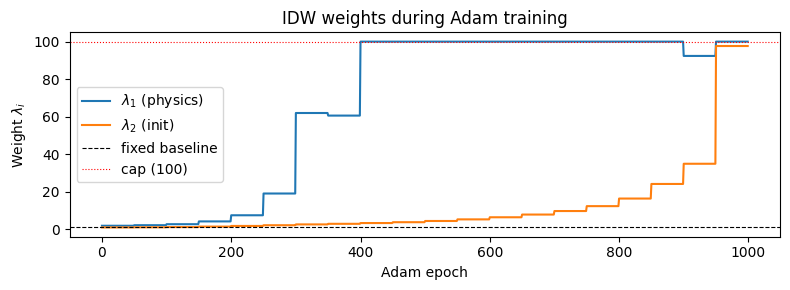

In [10]:
figure(figsize=(8, 3))
plot(lam1_hist, label=r'$\lambda_1$ (physics)')
plot(lam2_hist, label=r'$\lambda_2$ (init)')
axhline(1.0, color='k', lw=0.8, ls='--', label='fixed baseline')
axhline(lam_max, color='r', lw=0.8, ls=':', label=f'cap ({lam_max:.0f})')
xlabel('Adam epoch');  ylabel(r'Weight $\lambda_i$')
title('IDW weights during Adam training')
legend();  tight_layout();  show()


In [11]:
optimizer_lb = torch.optim.LBFGS(
    model.parameters(), lr=0.1, max_iter=20,
    history_size=50, line_search_fn='strong_wolfe'
)

lbfgs_hist = []

for epoch in range(300):
    def closure():
        optimizer_lb.zero_grad()
        loss, *_ = compute_loss(
            model, t_tr, x0n_tr, un_tr, xm_tr, x0p_tr)
        loss.backward()
        return loss
    loss_val = optimizer_lb.step(closure)
    lbfgs_hist.append(loss_val.item())
    if (epoch + 1) % 50 == 0:
        print(f'L-BFGS epoch {epoch+1:3d}  loss={loss_val.item():.4e}')

L-BFGS epoch  50  loss=3.3302e-03
L-BFGS epoch 100  loss=1.0952e-03
L-BFGS epoch 150  loss=4.5213e-04
L-BFGS epoch 200  loss=3.0638e-04
L-BFGS epoch 250  loss=2.3644e-04
L-BFGS epoch 300  loss=2.0022e-04


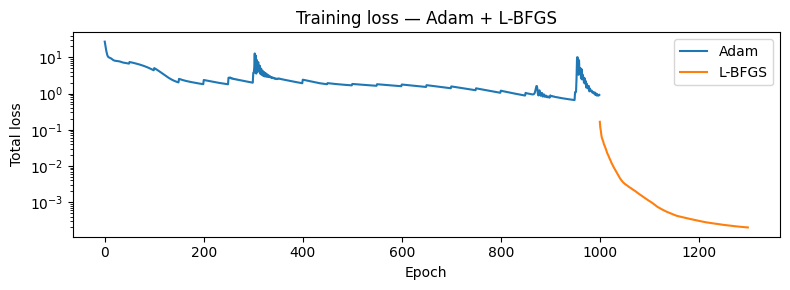

In [12]:
figure(figsize=(8, 3))
semilogy(loss_hist, label='Adam')
semilogy(range(n_epochs, n_epochs + len(lbfgs_hist)), lbfgs_hist, label='L-BFGS')
xlabel('Epoch');  ylabel('Total loss');  legend()
title('Training loss — Adam + L-BFGS')
tight_layout();  show()

## 9. Evaluation — Measured States

Compare the PINN predictions of $c_A, c_B, T, T_K$ on the test set
against the ground-truth trajectories.

In [13]:
from sklearn.metrics import r2_score

model.eval()
with torch.no_grad():
    inp_te  = torch.cat([t_te, x0n_te, un_te], dim=1)
    pred_te = model(inp_te).cpu().numpy()   # (N_test*N_t, 7)

xm_te_np = xm_te.cpu().numpy()             # (N_test*N_t, 4)

state_labels = ['$c_A$', '$c_B$', '$T$', '$T_K$']
for j, label in enumerate(state_labels):
    r2 = r2_score(xm_te_np[:, j], pred_te[:, j])
    print(f'  {label:6s}  R² = {r2:.4f}')

  $c_A$   R² = 0.9972
  $c_B$   R² = 0.9969
  $T$     R² = 0.9997
  $T_K$   R² = 0.9996


### Trajectory Plot

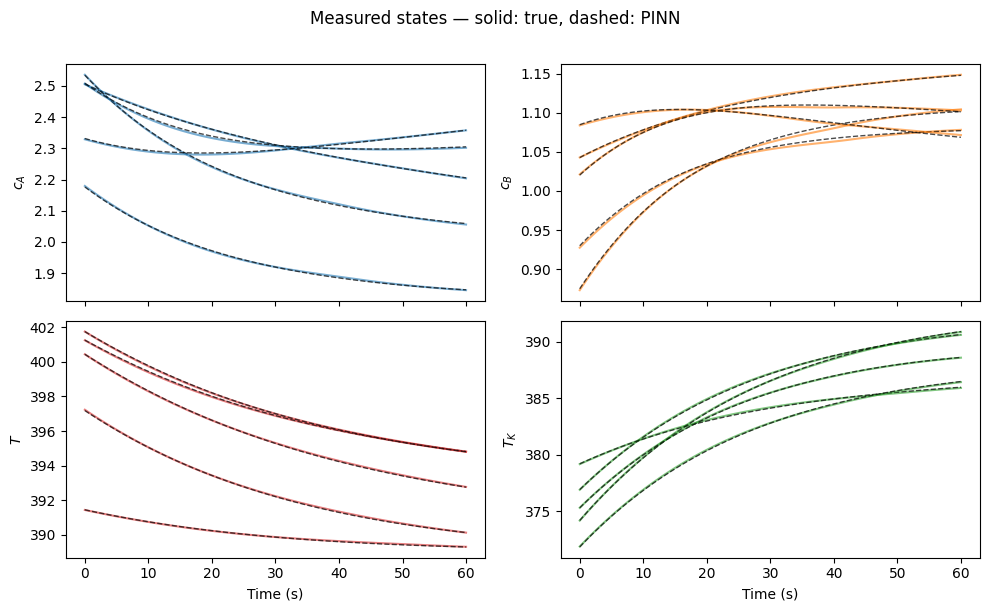

In [14]:
N_te = len(test_idx)
pred_te_3d = pred_te.reshape(N_te, N_t, 7)
xm_te_3d   = xm_te_np.reshape(N_te, N_t, 4)

colors = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green']
fig, axes = subplots(2, 2, figsize=(10, 6), sharex=True)

for ax, j, label, c in zip(axes.flat, range(4), state_labels, colors):
    for i in range(min(5, N_te)):
        ax.plot(t_s, xm_te_3d[i, :, j], '-',  color=c, alpha=0.6, lw=1.5)
        ax.plot(t_s, pred_te_3d[i, :, j], '--', color='k', alpha=0.7, lw=1)
    ax.set_ylabel(label)

axes[1, 0].set_xlabel('Time (s)');  axes[1, 1].set_xlabel('Time (s)')
suptitle('Measured states — solid: true, dashed: PINN', y=1.01)
tight_layout();  show()

## 10. Evaluation — Inferred Rate Constants

Compare the PINN-inferred $k_1, k_2, k_3$ against the ground truth computed
from $T(t)$ via the Arrhenius equation — the target the PINN was never shown.

In [15]:
K_true_te = K_true[test_idx].reshape(N_te * N_t, 3)  # ground truth
K_pred_te = pred_te[:, 4:]                            # PINN output

k_labels = ['$k_1$', '$k_2$', '$k_3$']
for j, label in enumerate(k_labels):
    r2 = r2_score(K_true_te[:, j], K_pred_te[:, j])
    print(f'  {label:6s}  R² = {r2:.4f}')

  $k_1$   R² = 0.9662
  $k_2$   R² = 0.9413
  $k_3$   R² = 0.9646


### Trajectory Plot

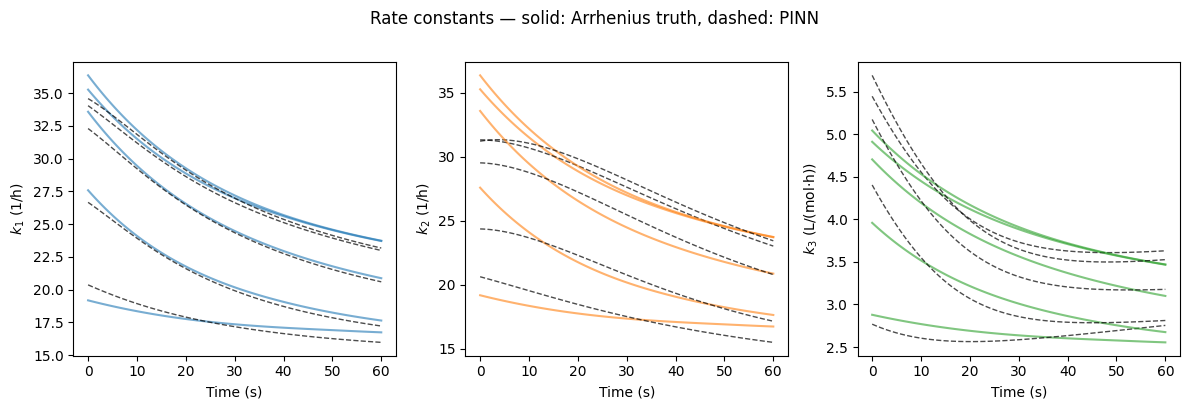

In [16]:
k_colors = ['tab:blue', 'tab:orange', 'tab:green']
k_units  = ['1/h', '1/h', 'L/(mol·h)']

K_pred_3d = K_pred_te.reshape(N_te, N_t, 3)
K_true_3d = K_true[test_idx]

fig, axes = subplots(1, 3, figsize=(12, 4), sharex=True)
for ax, j, label, c, unit in zip(axes, range(3), k_labels, k_colors, k_units):
    for i in range(min(5, N_te)):
        ax.plot(t_s, K_true_3d[i, :, j],  '-',  color=c, alpha=0.6, lw=1.5)
        ax.plot(t_s, K_pred_3d[i, :, j],  '--', color='k', alpha=0.7, lw=1)
    ax.set_ylabel(f'{label} ({unit})')
    ax.set_xlabel('Time (s)')

suptitle('Rate constants — solid: Arrhenius truth, dashed: PINN', y=1.01)
tight_layout();  show()

### Per-Trajectory R²

The global R² reported above can be misleadingly high: the rate constants vary
greatly *across* trajectories (different operating conditions → different temperatures),
so even a model that captures only the between-trajectory spread achieves a high R².

Per-trajectory R² — computed within each test trajectory separately —
reveals how well the PINN tracks $k_i(t)$ over time for a fixed set of conditions.

Per-trajectory R² (mean ± std):
  $k_1$   -5.145 ± 9.799  (min -33.990)
  $k_2$   -20.611 ± 45.455  (min -172.575)
  $k_3$   -18.504 ± 45.796  (min -171.278)


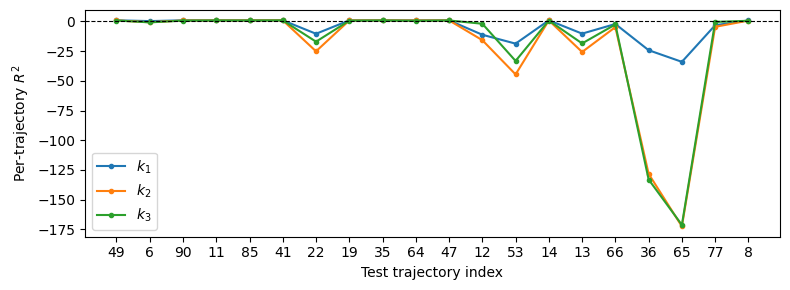

In [17]:
K_pred_3d = K_pred_te.reshape(N_te, N_t, 3)
K_true_3d = K_true[test_idx]

r2_traj = np.array([
    [r2_score(K_true_3d[i, :, j], K_pred_3d[i, :, j]) for j in range(3)]
    for i in range(N_te)
])  # (N_te, 3)

print('Per-trajectory R² (mean ± std):')
for j, label in enumerate(k_labels):
    r = r2_traj[:, j]
    print(f'  {label:6s}  {r.mean():.3f} ± {r.std():.3f}  (min {r.min():.3f})')

figure(figsize=(8, 3))
for j, (label, col) in enumerate(zip(k_labels, ['C0','C1','C2'])):
    plot(range(N_te), r2_traj[:, j], '.-', color=col, label=label)
axhline(0, color='k', lw=0.8, ls='--')
xlabel('Test trajectory index');  ylabel('Per-trajectory $R^2$')
xticks(range(N_te), test_idx)
legend();  tight_layout();  show()


Text(0.5, 1.0, 'Trajectory 0: $k_1$ ground truth')

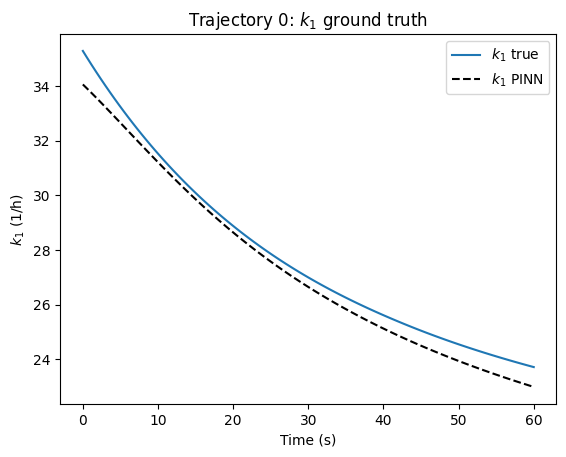

In [26]:
plot(t_s, K_true_3d[0, :, 0], '-', color='C0', label='$k_1$ true')
plot(t_s, K_pred_3d[0, :, 0], '--', color='k', label='$k_1$ PINN')
legend()
xlabel('Time (s)');  ylabel('$k_1$ (1/h)')
title('Trajectory 0: $k_1$ ground truth')

### MAPE

The Mean Absolute Percentage Error measures relative prediction error:

$$\text{MAPE}_i = \frac{100}{N_t} \sum_{t} \frac{|\hat{k}_i(t) - k_i(t)|}{|k_i(t)|}$$



In [18]:
def mape(true, pred, axis=None):
    """Mean absolute percentage error, ignoring near-zero true values."""
    mask = np.abs(true) > 1e-8
    return 100 * np.mean(np.abs((pred[mask] - true[mask]) / true[mask]))

mape_traj = np.array([
    [mape(K_true_3d[i, :, j], K_pred_3d[i, :, j]) for j in range(3)]
    for i in range(N_te)
])  # (N_te, 3)

# Overall MAPE: computed point-wise across all test trajectories
K_true_flat = K_true_3d.reshape(-1, 3)
K_pred_flat = K_pred_3d.reshape(-1, 3)

K_mape = [mape(K_true_flat[:, j], K_pred_flat[:, j]) for j in range(3)]
K_mape_Velioglu = [2.90, 6.13, 6.98]

print('          MAPE     MAPE (Velioglu)')
for j, label in enumerate(k_labels):
    print(f'  {label:6s}  {K_mape[j]:.2f}%    {K_mape_Velioglu[j]:.2f}%')


          MAPE     MAPE (Velioglu)
  $k_1$   2.98%    2.90%
  $k_2$   4.61%    6.13%
  $k_3$   4.00%    6.98%


Results are in the same ballpark. Differences are expected since training/test splits differ.
Velioglu et al. report averages over 25 models (5 runs $\times$ 5 dataset splits).

### R² and MAPE vs $\Delta T_0$

The initial temperature difference $T_0 - T_{K,0}$ controls how much the temperature varies
within a trajectory — and therefore how informative the ODE residuals are for identifying $k_i$.

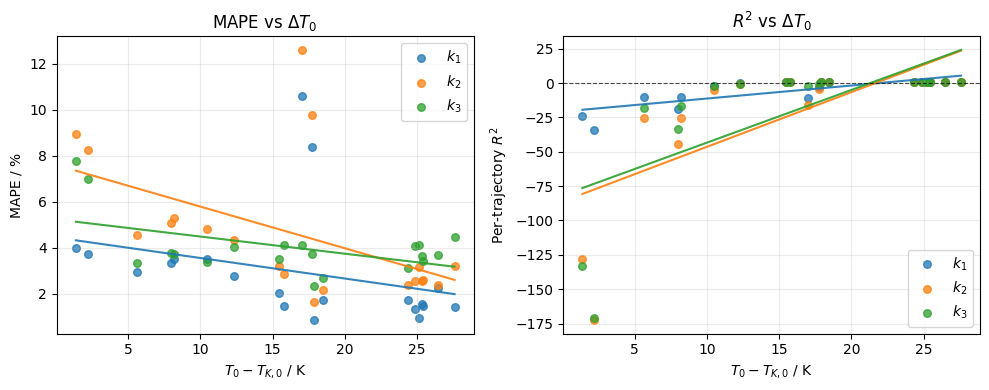

In [27]:
# Initial temperature difference for each test trajectory
dT0 = X0[test_idx, 2] - X0[test_idx, 3]   # T0 - TK0 (K), shape (N_te,)

# Sort by ΔT0 for cleaner trend lines
order = np.argsort(dT0)
dT0_s = dT0[order]

colors = ['C0', 'C1', 'C2']
fig, axes = subplots(1, 2, figsize=(10, 4))
ax1, ax2 = axes

for j, (label, col) in enumerate(zip(k_labels, colors)):
    m_j = mape_traj[:, j]
    r_j = r2_traj[:, j]

    # Scatter points (one point per test trajectory)
    ax1.scatter(dT0, m_j, color=col, alpha=0.75, s=30, label=label)
    ax2.scatter(dT0, r_j, color=col, alpha=0.75, s=30, label=label)

    # Linear trend lines for visual comparison
    p_m = np.polyfit(dT0, m_j, 1)
    p_r = np.polyfit(dT0, r_j, 1)
    ax1.plot(dT0_s, np.polyval(p_m, dT0_s), color=col, lw=1.5, alpha=0.9)
    ax2.plot(dT0_s, np.polyval(p_r, dT0_s), color=col, lw=1.5, alpha=0.9)

ax1.set_xlabel(r'$T_0 - T_{K,0}$ / K');  ax1.set_ylabel('MAPE / %')
ax1.set_title(r'MAPE vs $\Delta T_0$')
ax1.grid(alpha=0.25)
ax1.legend()

ax2.set_xlabel(r'$T_0 - T_{K,0}$ / K');  ax2.set_ylabel('Per-trajectory $R^2$')
ax2.set_title(r'$R^2$ vs $\Delta T_0$')
ax2.axhline(0, color='k', lw=0.8, ls='--', alpha=0.7)
ax2.grid(alpha=0.25)
ax2.legend()

tight_layout();  show()

## 11. Arrhenius Parameter Estimation via curve_fit

The PINN predicts $\hat{k}_i(t)$ and $\hat{T}(t)$ across all test trajectories.
Fitting the Arrhenius equation to the full test set in one pass:

$$\ln \hat{k}_i = \ln k_{i0} + \frac{E_a}{T}$$

gives a single estimate of $k_{i0}$ and $E_a$ with confidence intervals
from the `curve_fit` covariance matrix.

In [20]:
from scipy.optimize import curve_fit
import numpy as np

# True Arrhenius parameters (Table 2)
true_params = {
    'k1': (1.287e12, -9758.3),
    'k2': (1.287e12, -9758.3),
    'k3': (9.043e9,  -8560.0),
}

def arrhenius_log(T, ln_k0, Ea):
    return ln_k0 + Ea / T

# Flatten all test predictions
T_all = pred_te[:, 2]       # predicted T / K,  (N_te*N_t,)
K_all = pred_te[:, 4:]      # predicted k1,k2,k3, (N_te*N_t, 3)

k_labels_plain = ['k1', 'k2', 'k3']
fit_results = {}   # store (popt, pcov) for plotting

print(f'{"":6s}  {"k_i0 fitted":>19s}  {"k_i0 true":>20s}  {"Ea fitted":>16s}  {"Ea true":>13s}')
for j, label in enumerate(k_labels_plain):
    k_j  = K_all[:, j]
    mask = k_j > 0
    popt, pcov = curve_fit(
        arrhenius_log, T_all[mask], np.log(k_j[mask]),
        p0=[np.log(true_params[label][0]), true_params[label][1]]
    )
    perr = np.sqrt(np.diag(pcov))
    fit_results[label] = (popt, pcov)
    k0_fit = np.exp(popt[0]);  k0_err = k0_fit * perr[0]
    print(f'{label:6s}  {k0_fit:14.3e} ± {k0_err:.2e}  {true_params[label][0]:14.3e}  '
          f'{popt[1]:12.1f} ± {perr[1]:.1f}  {true_params[label][1]:10.1f}')


                k_i0 fitted             k_i0 true         Ea fitted        Ea true
k1           6.274e+11 ± 3.89e+10       1.287e+12       -9484.5 ± 24.4     -9758.3
k2           8.291e+11 ± 9.05e+10       1.287e+12       -9594.4 ± 42.9     -9758.3
k3           6.944e+09 ± 6.45e+08       9.043e+09       -8453.3 ± 36.5     -8560.0


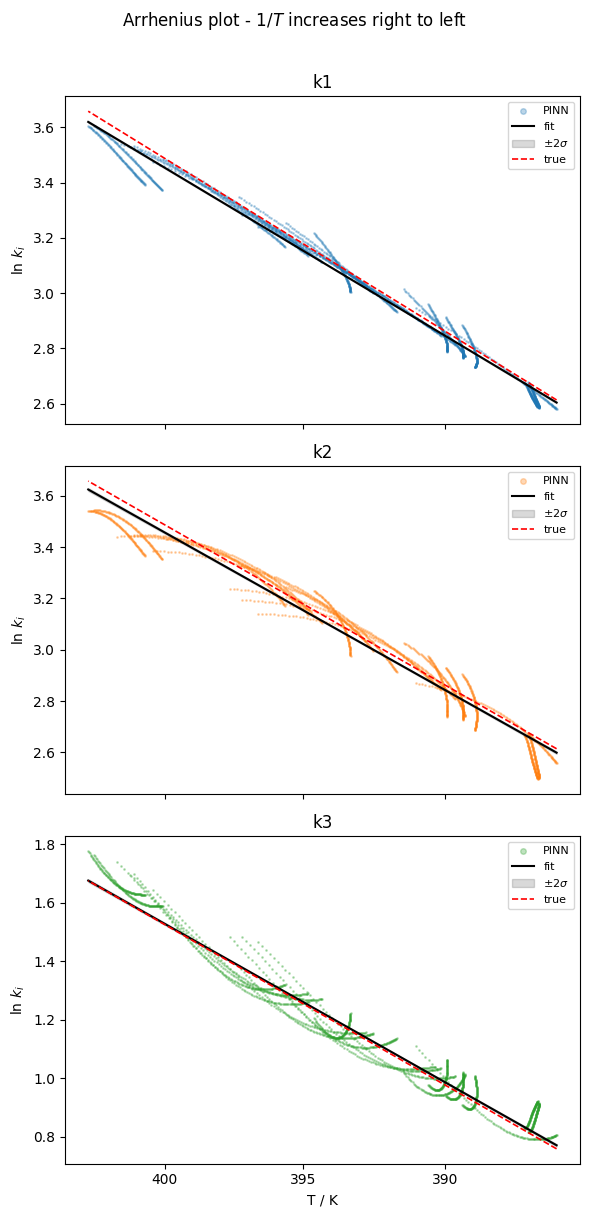

In [28]:
colors = ['C0', 'C1', 'C2']
inv_T_all = 1.0 / T_all

# Tick positions: nice T values spanning the data range
T_ticks     = np.arange(np.ceil(T_all.min()/5)*5,
                        np.floor(T_all.max()/5)*5 + 1, 5).astype(int)
inv_T_ticks = 1.0 / T_ticks

fig, axes = subplots(3, 1, figsize=(6, 12), sharex=True)
for ax, j, label, col in zip(axes, range(3), k_labels_plain, colors):
    k_j  = K_all[:, j]
    mask = k_j > 0

    ax.scatter(inv_T_all[mask], np.log(k_j[mask]),
               s=1, color=col, alpha=0.3, label='PINN')

    popt, pcov = fit_results[label]
    T_range     = np.linspace(T_all.min(), T_all.max(), 300)
    inv_T_range = 1.0 / T_range
    y_fit = arrhenius_log(T_range, *popt)
    y_var = (pcov[0,0]
             + inv_T_range**2 * pcov[1,1]
             + 2 * inv_T_range * pcov[0,1])
    y_std = np.sqrt(np.maximum(y_var, 0))
    ax.plot(inv_T_range, y_fit, 'k-', lw=1.5, label='fit')
    ax.fill_between(inv_T_range, y_fit - 2*y_std, y_fit + 2*y_std,
                    color='k', alpha=0.15, label=r'$\pm 2\sigma$')

    k0_true, Ea_true = true_params[label]
    ax.plot(inv_T_range, np.log(k0_true) + Ea_true * inv_T_range,
            'r--', lw=1.2, label='true')

    ax.set_xticks(inv_T_ticks)
    ax.set_xticklabels(T_ticks)
    ax.set_ylabel(r'$\ln\, k_i$')
    ax.set_title(label)
    ax.legend(fontsize=8, markerscale=4)

axes[-1].set_xlabel('T / K')
suptitle('Arrhenius plot - $1/T$ increases right to left', y=1.01)
tight_layout();  show()


## 12. Save Results

In [22]:
torch.save(model.state_dict(), 'pinn_idw_model.pt')

In [23]:
np.savez('pinn_idw_results.npz',
  K_pred_3d  = K_pred_3d,        # (N_te, N_t, 3)  PINN rate constant predictions
  K_true_3d  = K_true[test_idx], # (N_te, N_t, 3)  ground truth
  pred_te_3d = pred_te.reshape(N_te, N_t, 7),  # all 7 outputs
  xm_te_3d   = xm_te_np.reshape(N_te, N_t, 4), # measured states
  r2_traj    = r2_traj,           # (N_te, 3)  per-trajectory R²
  X0_te      = X0[test_idx],      # (N_te, 4)  initial conditions
  U_te       = U[test_idx],       # (N_te, 2)  inputs
  t_s        = t_s,               # (N_t,)     time vector
  test_idx   = test_idx,
)

## 13. Variations

You: Re-run the notebook for the following conditions:

 - `lam_max = 1` (no IDW)
 - `lam_max = float('inf')`  (unrestricted IDW)

How do these variations effect the results?